# uGMRT FITS Metadata Queries (No Full Data Load)

This notebook provides lightweight query functions for uGMRT UVFITS files using memory mapping.
It focuses on metadata only: headers, antennas, frequencies, sources, and source scan times.

## Run Order Checklist
Use this quick order for a clean run from top to bottom.

- [ ] Step 1: Discover FITS Files
- [ ] Step 2: Inspect One FITS File
- [ ] **Step 2b: Build Row Index** ← one sequential pass, caches source/baseline/time arrays
- [ ] Step 3: Show Frequency Properties
- [ ] Step 4: List and Filter Sources
- [ ] Step 5: Compute Scan Windows (uses cached index)
- [ ] Step 6: Summarize Frequencies Across All FITS Files
- [ ] Step 7: Setup Plot Dependencies
- [ ] Step 8: Define Visibility Loader (uses cached index + block I/O)
- [ ] Step 9: Define Plotting Functions
- [ ] Step 10: Run Visibility Extraction and Plots
- [ ] Step 11: Validate GSB vs GWB Channel Counts

Tip: If the kernel restarts, rerun steps in order from Step 1.

In [ ]:
# Cell 2: Import Required Libraries
from pathlib import Path
from typing import Dict, List, Optional, Union

import numpy as np
from astropy.io import fits
from astropy.time import Time


In [ ]:
import importlib, sys

# Auto-reload so edits to ugmrt_query.py take effect without kernel restart
if 'ugmrt_query' in sys.modules:
    importlib.reload(sys.modules['ugmrt_query'])

from ugmrt_query import *

BASE_DIR = Path('/media/wasim/gmrt_40_014')
print('ugmrt_query module loaded — all functions available')

## Step 1: Discover FITS Files
Run the next cell to scan the base directory and list all FITS files.

In [ ]:
# Cell 9: Discovery - Find all FITS files
fits_files = find_fits_files(BASE_DIR)
for i, p in enumerate(fits_files, 1):
    print(f'{i:2d}. {p}')


## Step 2: Inspect One FITS File
Run the next cell to select one FITS file and print key metadata, antenna count, and source count.

In [ ]:
# Cell 10: Inspection - Pick one file and examine basic properties
target = fits_files[1]
print('Target:', target)

print('Key header properties:')
for k, v in get_key_header_properties(target).items():
    print(f'- {k}: {v}')

print('Antenna count:', len(list_antennas(target)))
print('Source count:', len(list_sources(target)))


## Step 2b: Build Row Index
One sequential pass over the FITS file reads **all** group parameters (~40 MB)
and caches source/baseline/time arrays in RAM.  Every subsequent query
(`get_source_observation_properties`, `load_vis_for_source`) uses this index
for direct seeking — no re-scanning of the 7.5 GB file.

In [ ]:
import time as _time
_t0 = _time.monotonic()
row_index = build_row_index(target)
print(f'\nTotal wall-clock: {_time.monotonic() - _t0:.1f}s')

## Step 3: Show Frequency Properties
Run the next cell to print channel count, bandwidth, and representative channel frequencies.

In [ ]:
# Cell 11: Frequency Properties - Detailed band information
freq = list_frequency_properties(target)
for k, v in freq.items():
    print(f'- {k}: {v}')


## Step 4: List and Filter Sources
Run the next cell to list source names and test exact-name and regex filters.

In [ ]:
# Cell 12: Source Discovery - List and filter sources
sources = list_sources(target)
print('All sources:')
for s in sources:
    print(s)

# Example subset by exact names
subset_exact = filter_sources(target, include=['Cas-A', '3C48'])
print('\nSubset exact:')
for s in subset_exact:
    print(s)

# Example subset by regex (sources beginning with 3C or B)
subset_regex = filter_sources(target, regex=r'^(3C|B)')
print('\nSubset regex ^(3C|B):', len(subset_regex), 'matches')

# List all 3C sources from the regex subset
subset_3c = [s for s in subset_regex if (s.get('source_name') or '').upper().startswith('3C')]
print('3C sources in subset regex:', len(subset_3c), 'matches')
for s in subset_3c:
    print(f"- ID={s['source_id']}, Name={s['source_name']}")

# MOON-specific regex example (case-insensitive match for names containing "MOON")
subset_moon = filter_sources(target, regex=r'(?i)moon')
print('\nSubset regex (?i)moon:', len(subset_moon), 'matches')
for s in subset_moon:
    print(f"- ID={s['source_id']}, Name={s['source_name']}")


## Step 5: Compute Scan Windows
Run the next cell to compute start and end scan windows for a selected source.

In [ ]:
# Source-level observation summary (uses cached row_index — no file re-read)
import time as _time
_t0 = _time.monotonic()
source_info = get_source_observation_properties(
    row_index,
    source='3C48',
    scan_gap_seconds=10.0,
    time_tolerance_seconds=1e-3,
    include_integrations=False,
)
_elapsed = _time.monotonic() - _t0

print('Source:', source_info['source_name'])
print('Visibility rows:', source_info['n_vis_rows'])
print('Integrations:', source_info['n_integrations'])
print('Scans:', source_info['n_scans'])
print('Integration time (s, inferred):', source_info['integration_time_sec'])
print('Requested scan gap (s):', source_info['requested_scan_gap_seconds'])
print('Effective scan gap (s):', source_info['effective_scan_gap_seconds'])
print('Autos present anywhere:', source_info.get('autos_present_anywhere'))
print('Baseline count per integration (min/median/max):',
      source_info.get('baseline_count_per_integration_min'),
      source_info.get('baseline_count_per_integration_median'),
      source_info.get('baseline_count_per_integration_max'))
print('Begin UTC:', source_info['begin_time_utc'])
print('End UTC  :', source_info['end_time_utc'])
print('Total duration (s):', source_info['total_duration_sec'])
print('Channels:', source_info['n_channels'])
print('Correlations:', source_info['n_correlations'])
print('bFreq (MHz):', source_info['bFreq_hz'] / 1e6)
print('eFreq (MHz):', source_info['eFreq_hz'] / 1e6)
print('Centre freq (MHz):', source_info['centre_freq_hz'] / 1e6)

print(f'\n[Computed in {_elapsed:.2f}s from cached index]')
print('\nFirst 5 scans:')
for r in source_info['scans'][:5]:
    print(r)

## Step 6: Summarize Frequencies Across All FITS Files
Run the next cell to print bFreq, eFreq, and cFreq for each FITS file.

In [ ]:
# Frequency summary (bFreq, eFreq, cFreq) for all FITS files
print(f"{'File':<55} {'bFreq_MHz':>12} {'eFreq_MHz':>12} {'cFreq_MHz':>12}")
print('-' * 93)
for p in fits_files:
    fp = list_frequency_properties(p)
    b = fp['freq_min_hz'] / 1e6
    e = fp['freq_max_hz'] / 1e6
    c = (b + e) / 2.0
    print(f"{p.name:<55} {b:>12.3f} {e:>12.3f} {c:>12.3f}")

## Visibility Plots - Source Inspection

Plot raw visibility amplitudes and spectra for a chosen source.

Controls available per plot:
- `SOURCE` - source name (e.g. `'3C48'`) or integer source ID
- `ANT_RANGE` - `(ant_min, ant_max)` inclusive; or `ant_list=[...]` for explicit antennas; `None` = all
- `CHAN_RANGE` - `(chan0, chan1)` 0-based inclusive; `None` = all channels
- `STOKES` - list of labels e.g. `['XX','YY']` or `None` for all correlations
- `MAX_ROWS` - safety cap on rows read (downsamples uniformly if exceeded)

## Step 7: Setup Plot Dependencies
Run the next cell to ensure matplotlib is installed and imported.

In [ ]:
import importlib
if importlib.util.find_spec('matplotlib') is None:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'matplotlib'])

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
print(f'matplotlib {matplotlib.__version__} ready')

## Step 10: Run Visibility Extraction and Plots
Run the next cell to choose file/source/filter settings and generate visibility plots.

In [ ]:
import importlib, sys

# Auto-reload so edits to ugmrt_query.py take effect without kernel restart
if 'ugmrt_query' in sys.modules:
    importlib.reload(sys.modules['ugmrt_query'])

from ugmrt_query import *


# USER CONFIGURATION - edit values below

VIS_FILE = Path(row_index['path'])
#SOURCE = '3C48'
SOURCE='MOON0520'

# Memory-safe defaults: narrower antenna set, mid-band channels, two correlations
# NOTE: GSB files have only 256 channels, so use valid range (0-255)
ANT_RANGE = None #(1, 16)
ANT_LIST = None #[1, 2, 28]  # None
CHAN_RANGE = (64, 191)  # Restrict to mid-band: 128 of 256 channels
STOKES = ['RR', 'LL']
MAX_ROWS = 30_000
SHOW_PHASE = False

# Choose fit model: 'disk', 'ring', 'annulus', 'composite', 'gaussian', or None
#FIT_MODEL = 'ring'      # thin ring (limb-bright Moon)
#FIT_MODEL = 'annulus'   # thick annulus (bright rim, dark interior)
FIT_MODEL = 'composite' # ring (thermal limb) + central Gaussian (reflected Earth RFI)
#FIT_MODEL = 'disk'      # classic uniform disk

print(f'File   : {VIS_FILE.name}')
print(f'Source : {SOURCE}')
print(f'Antenna: range={ANT_RANGE}, list={ANT_LIST}')
print(f'Chans  : {CHAN_RANGE}, Stokes={STOKES}, max_rows={MAX_ROWS}')
print(f'Fit    : {FIT_MODEL}')

vis = load_vis_for_source(
    row_index,
    source=SOURCE,
    ant_range=ANT_RANGE,
    ant_list=ANT_LIST,
    chan_range=CHAN_RANGE,
    stokes=STOKES,
    max_rows=MAX_ROWS,
)

print(f'\nLoaded rows: {vis["nrows"]:,}')
print(f'Stokes: {vis["stokes_labels"]}')
print(
    f'Freq range: {vis["freqs_hz"].min()/1e6:.3f} - {vis["freqs_hz"].max()/1e6:.3f} MHz '
    f'({len(vis["freqs_hz"])} channels)')
print(f'Unique baselines: {len(set(zip(vis["ant1"], vis["ant2"])))}\n')

tag = f'{SOURCE} | {VIS_FILE.name}'
plot_vis_amp_vs_uvdist(vis, title=tag, show_phase=SHOW_PHASE, fit=FIT_MODEL)

In [ ]:
import importlib, sys, re

if 'ugmrt_query' in sys.modules:
    importlib.reload(sys.modules['ugmrt_query'])
from ugmrt_query import *

# --- settings ---
CHAN_RANGE = (64, 191)
STOKES = ['RR', 'LL']
MAX_ROWS = 30_000
FIT_MODEL = 'composite'
SAVE_DIR = Path('/media/wasim/gmrt_40_014/work')

# Find all MOON sources
all_sources = list_sources(target)
moon_sources = [s for s in all_sources
                if re.search(r'(?i)moon', s.get('source_name', ''))]
print(f'Found {len(moon_sources)} MOON source(s):',
      [s['source_name'] for s in moon_sources])

for src in moon_sources:
    sname = src['source_name']
    print(f'\n{"="*60}')
    print(f'Processing: {sname}')
    print(f'{"="*60}')

    vis = load_vis_for_source(
        row_index,
        source=sname,
        chan_range=CHAN_RANGE,
        stokes=STOKES,
        max_rows=MAX_ROWS,
    )
    print(f'Loaded rows: {vis["nrows"]:,}')

    tag = f'{sname} | {Path(row_index["path"]).name}'
    safe_name = sname.replace(' ', '_').replace('+', 'p')
    save_file = SAVE_DIR / f'uvdist_{safe_name}_{FIT_MODEL}.png'

    plot_vis_amp_vs_uvdist(
        vis, title=tag, fit=FIT_MODEL, save_path=str(save_file))


## Step 11: Validate GSB vs GWB Channel Counts
Run the next cell to print channel counts and confirm backend differences.

In [ ]:
# Check channel counts for all files - GSB vs GWB
print(f"{'File':<50} {'nchan':>8} {'Type':<6}")
print('-' * 66)
for p in fits_files:
    fp = list_frequency_properties(p)
    nchan = fp['nchan']
    file_type = 'GSB' if 'gsb' in p.name.lower() else 'GWB'
    print(f"{p.name:<50} {nchan:>8} {file_type:<6}")


## Step 12: Derive 3C48 Bandpass Solutions
Use the working-copy GSB FITS file only. This writes a separate bandpass solution file and does not modify any FITS data.

Run the next cell to build a row index on the copied file, solve RR/LL bandpass gains from 3C48, and save the solution into `work/`.

In [ ]:
import importlib, sys
from pathlib import Path

if 'ugmrt_query' in sys.modules:
    importlib.reload(sys.modules['ugmrt_query'])
from ugmrt_query import *

CAL_FITS = Path('/media/wasim/gmrt_40_014/work/40_014_25JUL2021_copy/40_014_25jul2021_gsb.FITS')
BANDPASS_OUT = Path('/media/wasim/gmrt_40_014/work/3c48_bandpass_25jul_gsb.npz')

print('Calibration FITS:', CAL_FITS)
row_index_cal = build_row_index(CAL_FITS)

bandpass_sol = derive_point_source_bandpass(
    row_index_cal,
    source='3C48',
    stokes=('RR', 'LL'),
    reference_antenna=None,
    smooth_window=5,
    min_baselines=20,
    max_rows=150_000,
    ignore_autos=True,
 )

save_bandpass_solution(bandpass_sol, BANDPASS_OUT)

print('Saved bandpass solution to:', BANDPASS_OUT)
print('Reference antenna:', bandpass_sol['reference_antenna'])
print('Antenna count:', len(bandpass_sol['antenna_ids']))
print('Channels solved:', len(bandpass_sol['freqs_hz']))
print('Bad-data policy:', bandpass_sol['bad_data_policy'])

## Step 13: Plot All Antenna Bandpasses on One Page
Run the next cell to render a 6x5 antenna page. Each panel shows amplitude and phase versus frequency, with channel numbers on the top axis and frequency in MHz on the bottom axis.

In [ ]:
import importlib, sys

if 'ugmrt_query' in sys.modules:
    importlib.reload(sys.modules['ugmrt_query'])
from ugmrt_query import plot_bandpass_solution_grid

BANDPASS_PLOT = Path('/media/wasim/gmrt_40_014/work/3c48_bandpass_25jul_gsb_6x5.png')

plot_bandpass_solution_grid(
    bandpass_sol,
    rows=6,
    cols=5,
    figsize=(28, 36),
    skip_edge_channels=(10, 5),
    save_path=BANDPASS_PLOT,
    title='3C48 bandpass solutions | 25 Jul GSB | 6x5 antenna page',
)

print('Saved plot to:', BANDPASS_PLOT)


## Step 14: Verify On-the-Fly Corrected Visibilities
Run the next cell to apply the saved bandpass solution in memory and verify that the corrected 3C48 amplitudes are flatter versus uv-distance. This does not modify any FITS file.

[load_vis] 57,456 rows, 353 MB read, 23.1s
[plot] Excluded antennas [11]: dropped 4,104 rows, kept 53,352


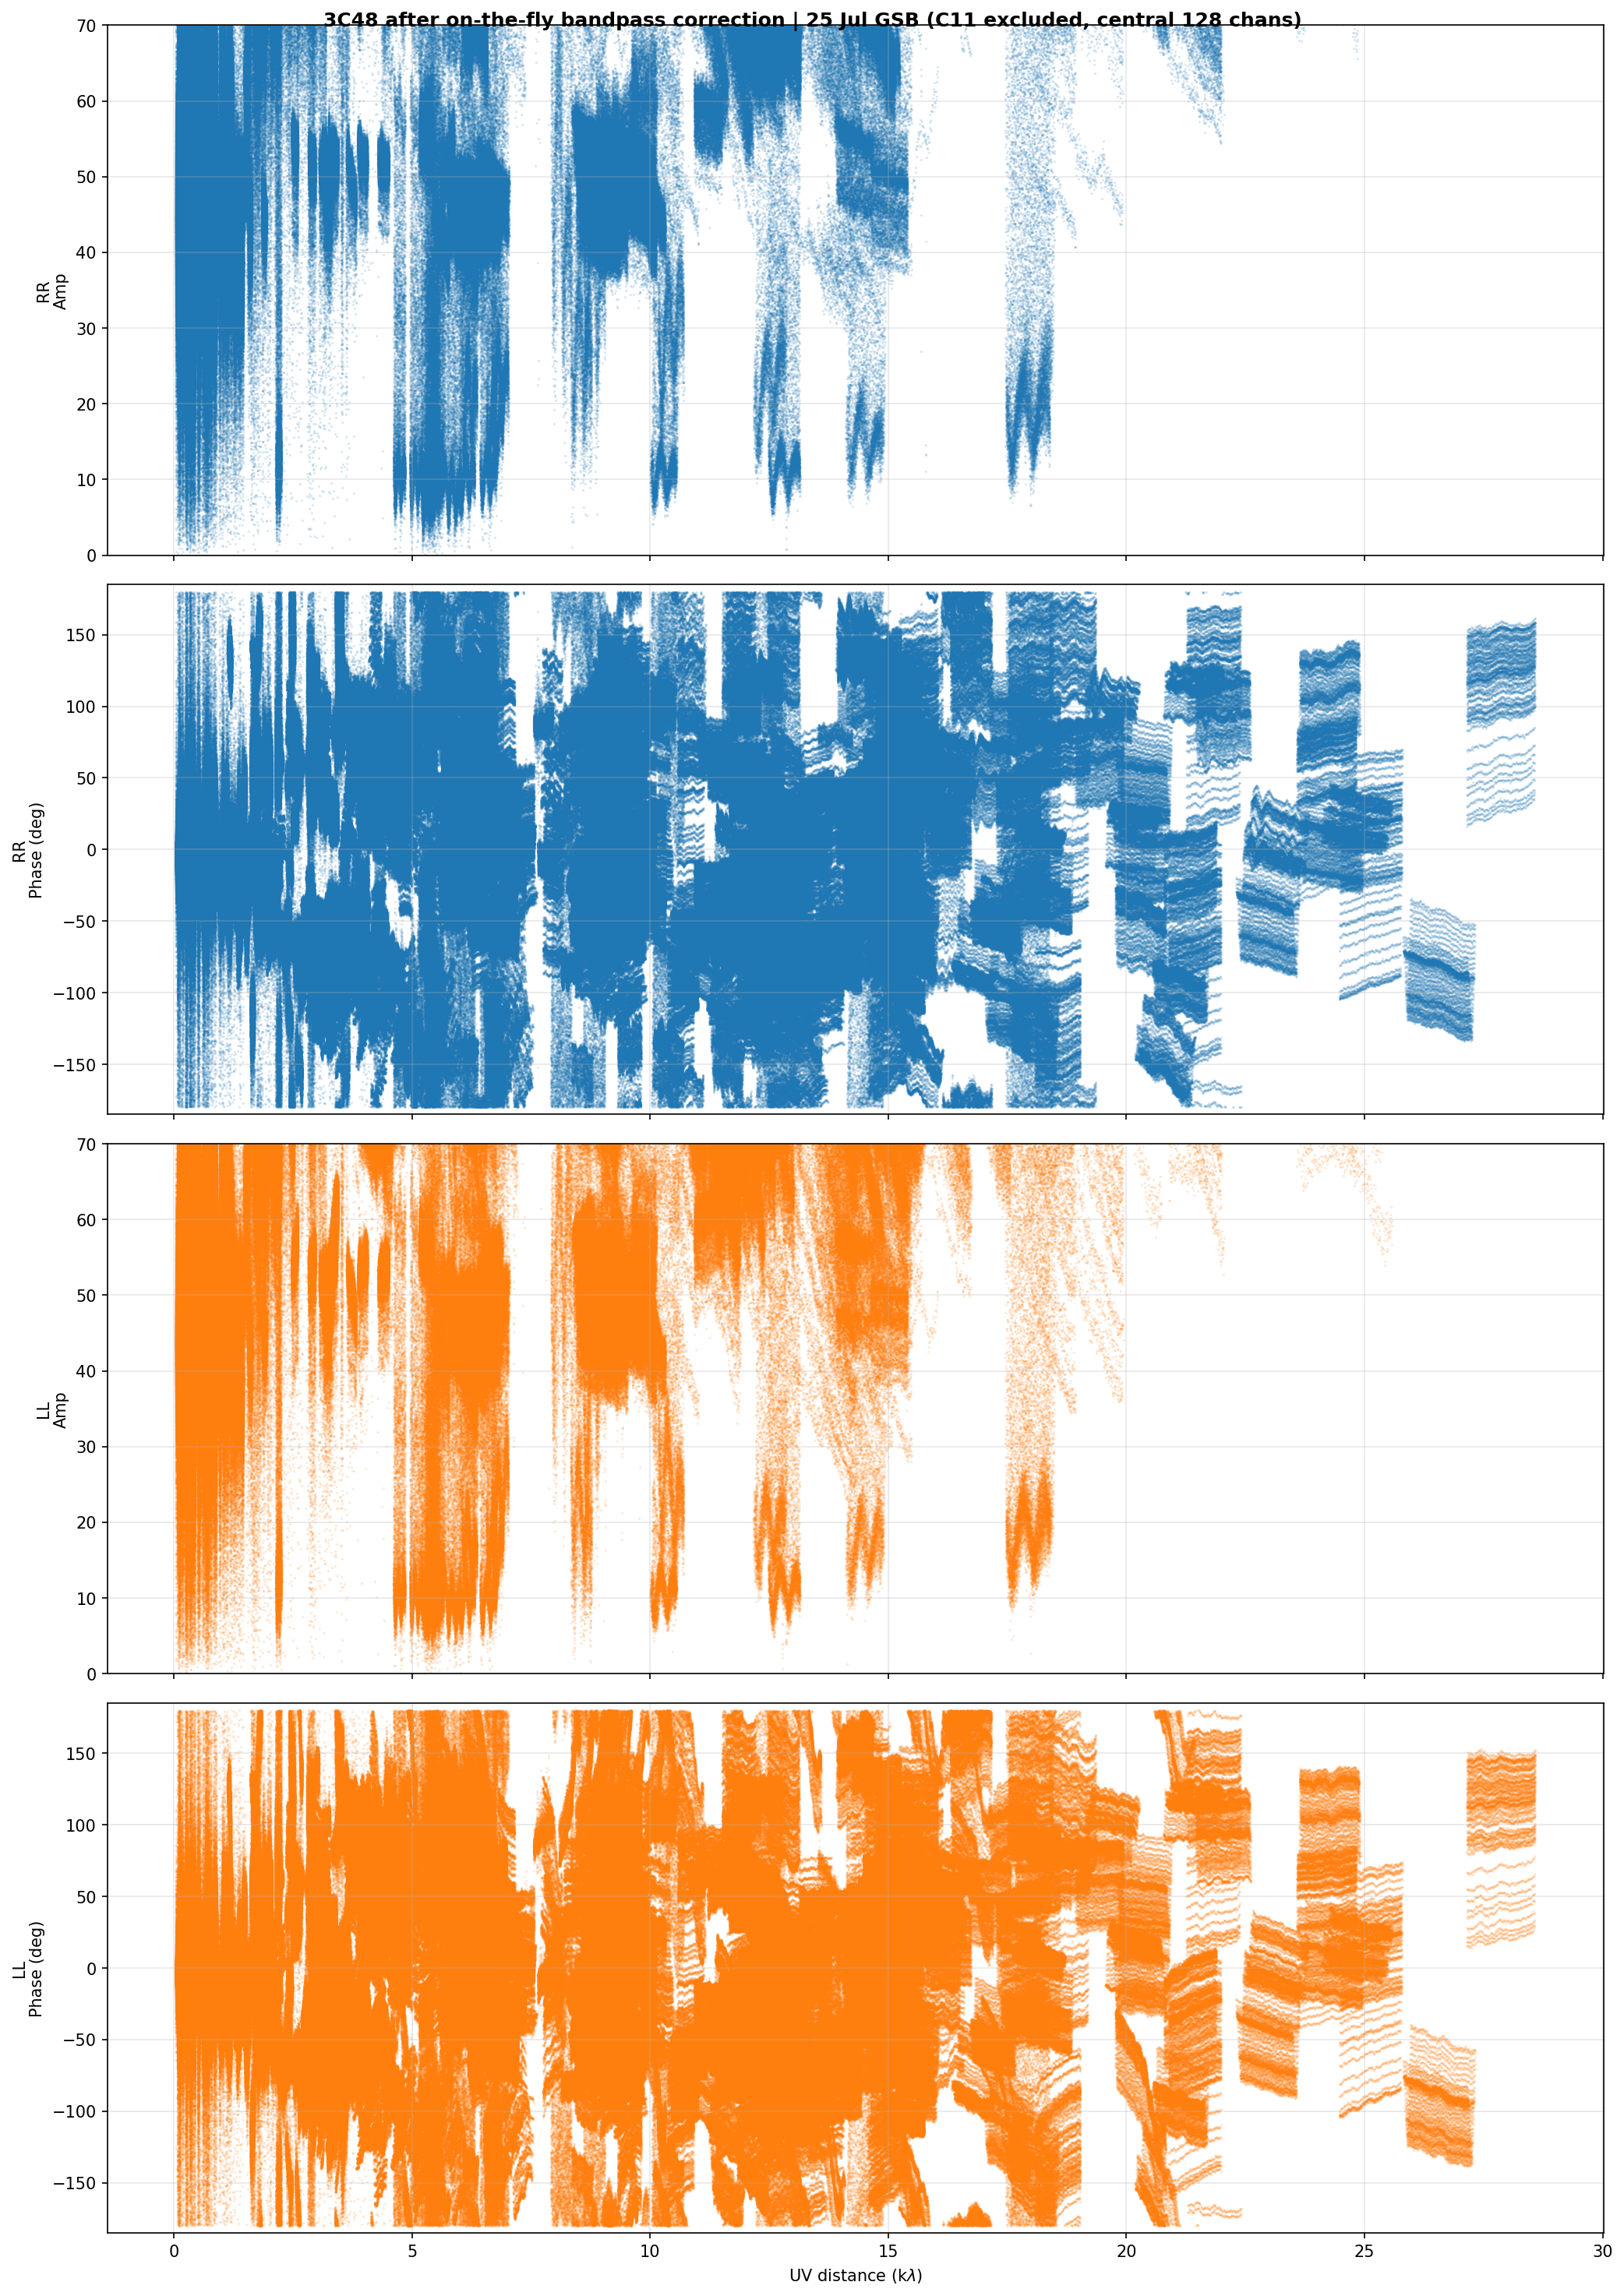

In [4]:
import importlib, sys
from pathlib import Path

if 'ugmrt_query' in sys.modules:
    importlib.reload(sys.modules['ugmrt_query'])
from ugmrt_query import build_row_index, load_bandpass_solution, load_vis_for_source, plot_bandpass_corrected_vis_amp_vs_uvdist

CAL_FITS = Path('/media/wasim/gmrt_40_014/work/40_014_25JUL2021_copy/40_014_25jul2021_gsb.FITS')
BANDPASS_OUT = Path('/media/wasim/gmrt_40_014/work/3c48_bandpass_25jul_gsb.npz')

# Build index in this step so plotting works after kernel restart.
#row_index_cal = build_row_index(CAL_FITS)

vis_3c48 = load_vis_for_source(
    row_index_cal,
    source='3C48',
    stokes=['RR', 'LL'],
    max_rows=60_000,
    ant_range=None,
    ant_list=None,
    chan_range=(64, 191),
 )

bandpass_sol_disk = load_bandpass_solution(BANDPASS_OUT)

plot_bandpass_corrected_vis_amp_vs_uvdist(
    vis_3c48,
    bandpass_sol_disk,
    title='3C48 after on-the-fly bandpass correction | 25 Jul GSB (C11 excluded, central 128 chans)',
    exclude_antennas=['C11:11'],
    amp_ylim=(0, 70),
    show_phase=True,
    fit=None,
 )


## Step 15: Proof #2 - Corrected Vector-Averaged Spectrum vs Perley-Butler Model
Run the next cell to load the same central 128 channels used in Step 14, plot the corrected vector-averaged real visibility spectrum of 3C48, overlay the Perley-Butler 2017 model, and show residuals in a bottom subpanel.

Because 3C48 is at phase centre, the real part of the vector-averaged corrected visibility is used as the flux estimator.

Index built: 1,312,794 rows, 13 sources, 31.5 MB RAM, 145.1s
         3C286 (id=1):   22,680 rows in 1 block(s)
         3C345 (id=2):   29,484 rows in 2 block(s)
         3C303 (id=3):   29,106 rows in 2 block(s)
       3C468.1 (id=4):  147,798 rows in 9 block(s)
         Cas-A (id=5):  672,084 rows in 7 block(s)
      B1929+10 (id=6):   28,728 rows in 1 block(s)
          3C48 (id=7):   57,456 rows in 2 block(s)
      MOON0520 (id=8):   42,714 rows in 1 block(s)
      MOON0545 (id=9):   42,714 rows in 1 block(s)
      MOON0605 (id=10):   41,580 rows in 1 block(s)
      MOON0625 (id=11):   14,742 rows in 1 block(s)
      MOON0635 (id=12):   14,364 rows in 1 block(s)
         DA240 (id=13):  169,344 rows in 1 block(s)
[load_vis] 57,456 rows, 353 MB read, 18.6s
[plot] Excluded antennas [11]: dropped 4,104 rows, kept 53,352


/media/wasim/gmrt_40_014/ugmrt_query.py:1446: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  show_phase=False,


[plot] Saved spectrum+residual plot to: /media/wasim/gmrt_40_014/work/3c48_corrected_vectoravg_vs_pb2017.png


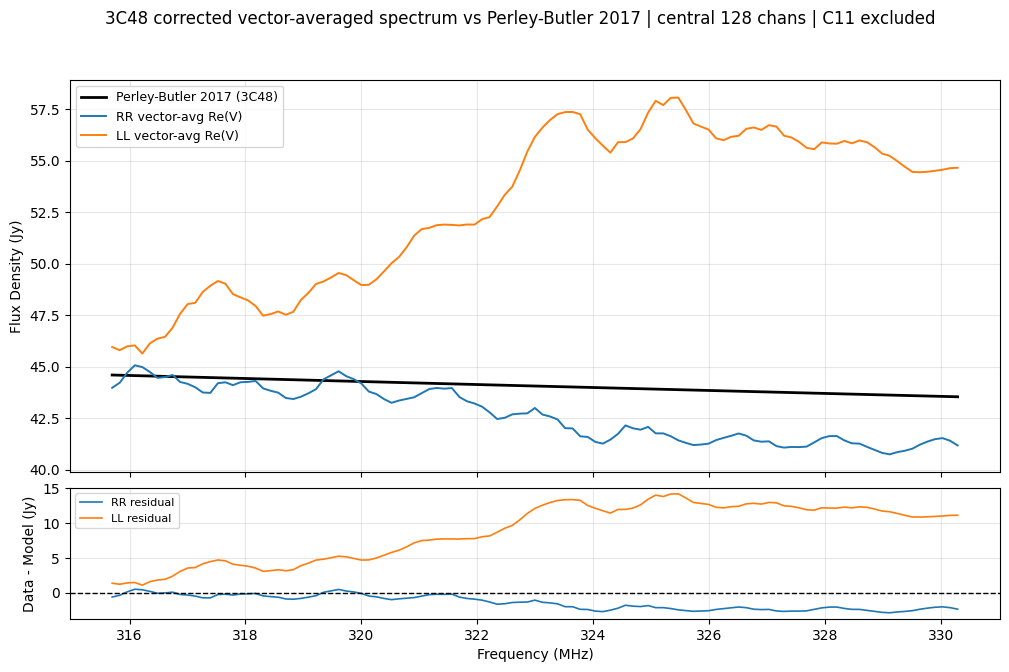

Perley-Butler 2017 model flux for 3C48 at 300 MHz: 45.79 Jy
Saved proof plot to: /media/wasim/gmrt_40_014/work/3c48_corrected_vectoravg_vs_pb2017.png
Plotted channel range: 64..191 (central 128 channels)


In [ ]:
import importlib, sys
from pathlib import Path

if 'ugmrt_query' in sys.modules:
    importlib.reload(sys.modules['ugmrt_query'])
from ugmrt_query import (
    build_row_index,
    load_bandpass_solution,
    load_vis_for_source,
    plot_corrected_vector_avg_spectrum,
    flux_model_3c48_perley_butler_2017,
    )

CAL_FITS = Path('/media/wasim/gmrt_40_014/work/40_014_25JUL2021_copy/40_014_25jul2021_gsb.FITS')
BANDPASS_OUT = Path('/media/wasim/gmrt_40_014/work/3c48_bandpass_25jul_gsb.npz')
SPECTRUM_PROOF_OUT = Path('/media/wasim/gmrt_40_014/work/3c48_corrected_vectoravg_vs_pb2017.png')
CHAN_RANGE = (64, 191)
SKIP_EDGE_CHANNELS = (10, 5)

# Keep this proof plot on the same central 128 channels used in Step 14.
row_index_cal = build_row_index(CAL_FITS)
vis_3c48 = load_vis_for_source(
    row_index_cal,
    source='3C48',
    stokes=['RR', 'LL'],
    max_rows=60_000,
    ant_range=None,
    ant_list=None,
    chan_range=CHAN_RANGE,
 )

bandpass_sol_disk = load_bandpass_solution(BANDPASS_OUT)

plot_corrected_vector_avg_spectrum(
    vis_3c48,
    bandpass_sol_disk,
    title='3C48 corrected vector-averaged spectrum vs Perley-Butler 2017 | central 128 chans | C11 excluded',
    exclude_antennas=['C11:11'],
    skip_edge_channels=SKIP_EDGE_CHANNELS,
    save_path=SPECTRUM_PROOF_OUT,
 )

s300 = float(flux_model_3c48_perley_butler_2017([300e6])[0])
skip_start, skip_end = SKIP_EDGE_CHANNELS
plot_chan_start = CHAN_RANGE[0] + skip_start
plot_chan_end = CHAN_RANGE[1] - skip_end
print(f'Perley-Butler 2017 model flux for 3C48 at 300 MHz: {s300:.2f} Jy')
print('Saved proof plot to:', SPECTRUM_PROOF_OUT)
print(f'Loaded channel range: {CHAN_RANGE[0]}..{CHAN_RANGE[1]} (central 128 channels)')
print(f'Plotted channel range after edge skip: {plot_chan_start}..{plot_chan_end}')

## Step 16: Diagnose RR vs LL Residuals
Run the next cell to compare RR and LL after bandpass correction, rank the worst antennas and baselines by residual against the Perley-Butler 2017 model, and identify what is driving the LL offset.

This step is self-contained and uses the same central 128 channels and edge trimming as Steps 14 and 15.

Index built: 1,312,794 rows, 13 sources, 31.5 MB RAM, 130.9s
         3C286 (id=1):   22,680 rows in 1 block(s)
         3C345 (id=2):   29,484 rows in 2 block(s)
         3C303 (id=3):   29,106 rows in 2 block(s)
       3C468.1 (id=4):  147,798 rows in 9 block(s)
         Cas-A (id=5):  672,084 rows in 7 block(s)
      B1929+10 (id=6):   28,728 rows in 1 block(s)
          3C48 (id=7):   57,456 rows in 2 block(s)
      MOON0520 (id=8):   42,714 rows in 1 block(s)
      MOON0545 (id=9):   42,714 rows in 1 block(s)
      MOON0605 (id=10):   41,580 rows in 1 block(s)
      MOON0625 (id=11):   14,742 rows in 1 block(s)
      MOON0635 (id=12):   14,364 rows in 1 block(s)
         DA240 (id=13):  169,344 rows in 1 block(s)
[load_vis] 57,456 rows, 353 MB read, 20.0s


/tmp/ipykernel_9104/3248492014.py:231: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.97))


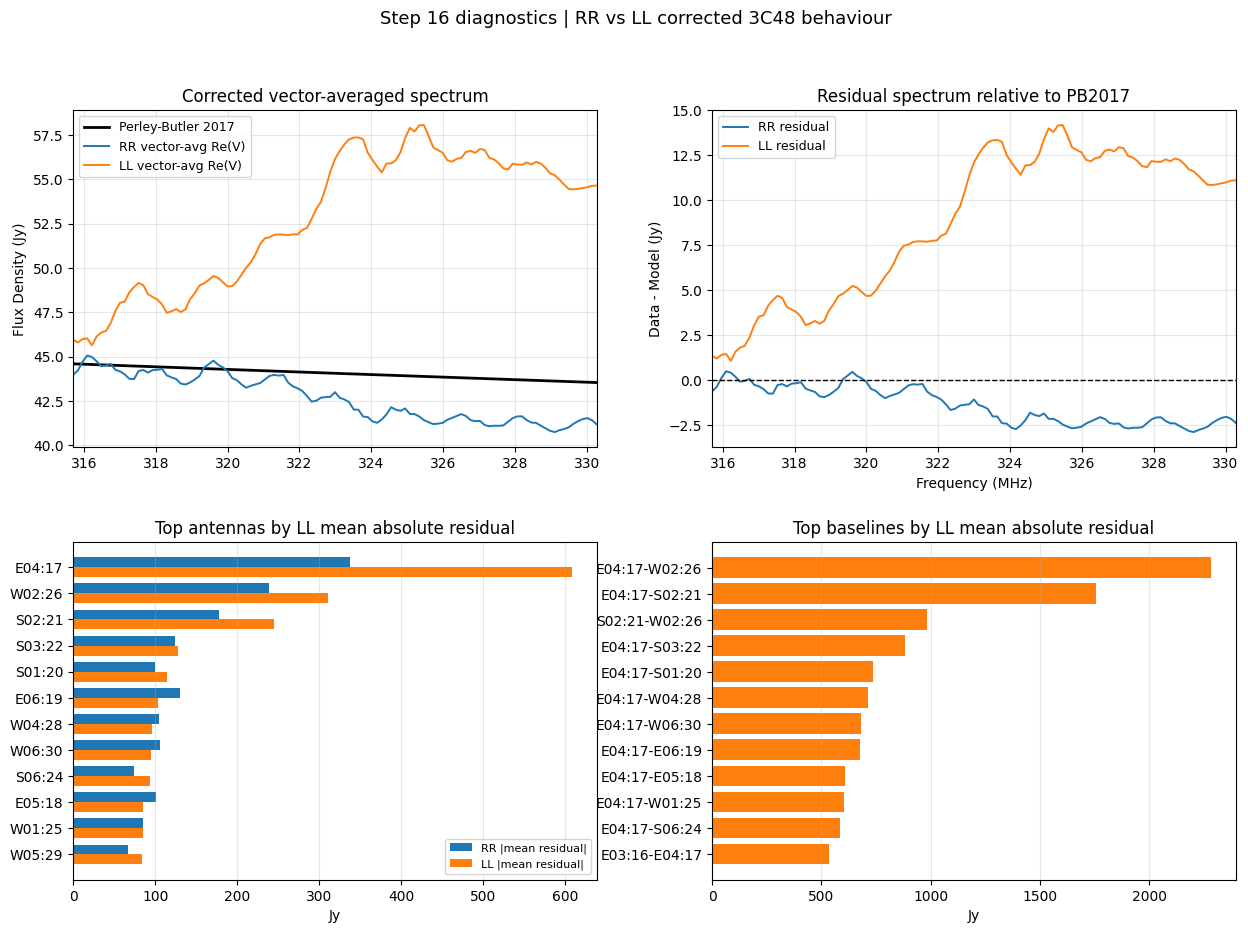

Excluded antenna IDs: [11]
Plotted frequency range: 315.701 .. 330.284 MHz

Top 8 antennas for RR by mean absolute residual:
  E04:17     mean_resid= 14.042 Jy  mean_abs_resid=338.182 Jy
  W02:26     mean_resid= 29.655 Jy  mean_abs_resid=238.263 Jy
  S02:21     mean_resid= 27.765 Jy  mean_abs_resid=177.562 Jy
  E06:19     mean_resid=-36.213 Jy  mean_abs_resid=130.417 Jy
  S03:22     mean_resid=-36.253 Jy  mean_abs_resid=124.054 Jy
  W06:30     mean_resid=-26.327 Jy  mean_abs_resid=106.326 Jy
  W04:28     mean_resid=-27.786 Jy  mean_abs_resid=105.044 Jy
  E05:18     mean_resid=-27.032 Jy  mean_abs_resid=100.871 Jy

Top 8 baselines for RR by mean absolute residual:
  E04:17-W02:26          mean_resid=1362.962 Jy  mean_abs_resid=1362.962 Jy
  E04:17-S02:21          mean_resid=1037.275 Jy  mean_abs_resid=1037.275 Jy
  E04:17-E06:19          mean_resid=-706.963 Jy  mean_abs_resid=706.992 Jy
  E04:17-S03:22          mean_resid=-655.949 Jy  mean_abs_resid=655.949 Jy
  S02:21-W02:26          m

In [6]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

if 'ugmrt_query' in sys.modules:
    importlib.reload(sys.modules['ugmrt_query'])
from ugmrt_query import (
    apply_bandpass_solution,
    build_row_index,
    flux_model_3c48_perley_butler_2017,
    load_bandpass_solution,
    load_vis_for_source,
    )

CAL_FITS = Path('/media/wasim/gmrt_40_014/work/40_014_25JUL2021_copy/40_014_25jul2021_gsb.FITS')
BANDPASS_OUT = Path('/media/wasim/gmrt_40_014/work/3c48_bandpass_25jul_gsb.npz')
CHAN_RANGE = (64, 191)
SKIP_EDGE_CHANNELS = (10, 5)
EXCLUDE_ANTENNAS = ['C11:11']
TOP_N = 12

def resolve_excluded_antenna_ids(solution, exclude_antennas):
    ant_ids = np.asarray(solution['antenna_ids'], dtype=np.int32)
    ant_names = list(solution.get('antenna_names') or [str(int(a)) for a in ant_ids])
    name_to_id = {str(name).strip().upper(): int(ant) for name, ant in zip(ant_names, ant_ids)}
    excluded_ids = set()
    for item in exclude_antennas:
        key = str(item).strip().upper()
        if key in name_to_id:
            excluded_ids.add(name_to_id[key])
            continue
        try:
            excluded_ids.add(int(item))
        except ValueError:
            pass
    return sorted(excluded_ids)

def filter_rows_by_antenna_ids(vis, excluded_ids):
    if not excluded_ids:
        return vis
    row_mask = (~np.isin(vis['ant1'], excluded_ids)) & (~np.isin(vis['ant2'], excluded_ids))
    vis_use = {}
    nrows = int(vis.get('nrows', len(vis['ant1'])))
    for key, value in vis.items():
        if isinstance(value, np.ndarray) and value.shape[:1] == (nrows,):
            vis_use[key] = value[row_mask]
        else:
            vis_use[key] = value
    vis_use['nrows'] = int(np.count_nonzero(row_mask))
    return vis_use

def weighted_channel_stat(values, weights, good_mask, use_abs=False):
    data = np.abs(values) if use_abs else values
    num = np.nansum(np.where(good_mask, weights * data, 0.0), axis=1)
    den = np.nansum(np.where(good_mask, weights, 0.0), axis=1)
    out = np.full(values.shape[0], np.nan, dtype=np.float64)
    ok = den > 0
    out[ok] = num[ok] / den[ok]
    return out

row_index_cal = build_row_index(CAL_FITS)
vis_3c48 = load_vis_for_source(
    row_index_cal,
    source='3C48',
    stokes=['RR', 'LL'],
    max_rows=60_000,
    ant_range=None,
    ant_list=None,
    chan_range=CHAN_RANGE,
    )
bandpass_sol_disk = load_bandpass_solution(BANDPASS_OUT)

excluded_ids = resolve_excluded_antenna_ids(bandpass_sol_disk, EXCLUDE_ANTENNAS)
vis_use = filter_rows_by_antenna_ids(vis_3c48, excluded_ids)
corrected = apply_bandpass_solution(vis_use, bandpass_sol_disk)

freqs_hz = np.asarray(corrected['freqs_hz'], dtype=np.float64)
freqs_mhz = freqs_hz / 1e6
model = flux_model_3c48_perley_butler_2017(freqs_hz)

skip_start, skip_end = SKIP_EDGE_CHANNELS
chan_mask = np.ones(freqs_hz.size, dtype=bool)
if skip_start > 0:
    chan_mask[:skip_start] = False
if skip_end > 0:
    chan_mask[-skip_end:] = False

plotted_freqs = freqs_mhz[chan_mask]
plot_freq_min = float(plotted_freqs[0])
plot_freq_max = float(plotted_freqs[-1])

vis_corr = np.asarray(corrected['vis_complex_corrected'], dtype=np.complex128)
weights = np.asarray(corrected['weight'], dtype=np.float64)
flagged = np.asarray(corrected.get('flagged_corrected', corrected.get('flagged')), dtype=bool)
stokes_labels = list(corrected['stokes_labels'])
ant1 = np.asarray(corrected['ant1'], dtype=np.int32)
ant2 = np.asarray(corrected['ant2'], dtype=np.int32)

ant_ids = np.asarray(bandpass_sol_disk['antenna_ids'], dtype=np.int32)
ant_names = list(bandpass_sol_disk.get('antenna_names') or [str(int(a)) for a in ant_ids])
ant_name_map = {int(ant): str(name) for ant, name in zip(ant_ids, ant_names)}

fig, axs = plt.subplots(2, 2, figsize=(15, 10), gridspec_kw={'hspace': 0.28, 'wspace': 0.22})
ax_spec, ax_resid = axs[0]
ax_ant, ax_base = axs[1]

model_plot = np.where(chan_mask, model, np.nan)
ax_spec.plot(freqs_mhz, model_plot, color='k', lw=2.0, label='Perley-Butler 2017')

pol_results = {}
unique_pairs, inv = np.unique(np.column_stack([ant1, ant2]), axis=0, return_inverse=True)

for pol_idx, pol in enumerate(stokes_labels):
    z = vis_corr[:, :, pol_idx]
    w = weights[:, :, pol_idx]
    good = (
        (~flagged[:, :, pol_idx])
        & np.isfinite(z.real)
        & np.isfinite(z.imag)
        & np.isfinite(w)
        & (w > 0)
        & chan_mask[None, :]
        )

    num = np.nansum(np.where(good, w * z, 0.0), axis=0)
    den = np.nansum(np.where(good, w, 0.0), axis=0)
    vec = np.full(freqs_hz.size, np.nan + 1j * np.nan, dtype=np.complex128)
    ok = den > 0
    vec[ok] = num[ok] / den[ok]
    real_spec = np.real(vec)
    resid_spec = real_spec - model

    ax_spec.plot(freqs_mhz, np.where(chan_mask, real_spec, np.nan), lw=1.4, label=f'{pol} vector-avg Re(V)')
    ax_resid.plot(freqs_mhz, np.where(chan_mask, resid_spec, np.nan), lw=1.4, label=f'{pol} residual')

    baseline_records = []
    for base_idx, (a1, a2) in enumerate(unique_pairs):
        row_sel = inv == base_idx
        if not np.any(row_sel):
            continue
        base_good = good[row_sel]
        base_w = w[row_sel]
        base_resid = np.real(z[row_sel]) - model[None, :]
        den_base = np.nansum(np.where(base_good, base_w, 0.0))
        if den_base <= 0:
            continue
        mean_resid = np.nansum(np.where(base_good, base_w * base_resid, 0.0)) / den_base
        mean_abs_resid = np.nansum(np.where(base_good, base_w * np.abs(base_resid), 0.0)) / den_base
        baseline_records.append({
            'pair': (int(a1), int(a2)),
            'label': f"{ant_name_map.get(int(a1), a1)}-{ant_name_map.get(int(a2), a2)}",
            'mean_resid': float(mean_resid),
            'mean_abs_resid': float(mean_abs_resid),
            })

    antenna_records = []
    for ant in np.unique(np.concatenate([ant1, ant2])):
        row_sel = (ant1 == ant) | (ant2 == ant)
        if not np.any(row_sel):
            continue
        ant_good = good[row_sel]
        ant_w = w[row_sel]
        ant_resid = np.real(z[row_sel]) - model[None, :]
        den_ant = np.nansum(np.where(ant_good, ant_w, 0.0))
        if den_ant <= 0:
            continue
        mean_resid = np.nansum(np.where(ant_good, ant_w * ant_resid, 0.0)) / den_ant
        mean_abs_resid = np.nansum(np.where(ant_good, ant_w * np.abs(ant_resid), 0.0)) / den_ant
        antenna_records.append({
            'ant': int(ant),
            'label': ant_name_map.get(int(ant), str(int(ant))),
            'mean_resid': float(mean_resid),
            'mean_abs_resid': float(mean_abs_resid),
            })

    baseline_records.sort(key=lambda item: item['mean_abs_resid'], reverse=True)
    antenna_records.sort(key=lambda item: item['mean_abs_resid'], reverse=True)
    pol_results[pol] = {
        'baseline_records': baseline_records,
        'antenna_records': antenna_records,
        }

ax_spec.set_title('Corrected vector-averaged spectrum')
ax_spec.set_ylabel('Flux Density (Jy)')
ax_spec.grid(True, alpha=0.3)
ax_spec.legend(fontsize=9, loc='best')

ax_resid.axhline(0.0, color='k', lw=1.0, ls='--')
ax_resid.set_title('Residual spectrum relative to PB2017')
ax_resid.set_ylabel('Data - Model (Jy)')
ax_resid.grid(True, alpha=0.3)
ax_resid.legend(fontsize=9, loc='best')

rr_ant = {item['label']: item['mean_abs_resid'] for item in pol_results['RR']['antenna_records']}
ll_ant_top = pol_results['LL']['antenna_records'][:TOP_N]
labels_ant = [item['label'] for item in ll_ant_top]
rr_vals = [rr_ant.get(label, np.nan) for label in labels_ant]
ll_vals = [item['mean_abs_resid'] for item in ll_ant_top]
ypos = np.arange(len(labels_ant))
height = 0.38
ax_ant.barh(ypos - height / 2.0, rr_vals, height=height, label='RR |mean residual|')
ax_ant.barh(ypos + height / 2.0, ll_vals, height=height, label='LL |mean residual|')
ax_ant.set_yticks(ypos)
ax_ant.set_yticklabels(labels_ant)
ax_ant.invert_yaxis()
ax_ant.set_xlabel('Jy')
ax_ant.set_title('Top antennas by LL mean absolute residual')
ax_ant.grid(True, axis='x', alpha=0.3)
ax_ant.legend(fontsize=8, loc='best')

ll_base_top = pol_results['LL']['baseline_records'][:TOP_N]
labels_base = [item['label'] for item in ll_base_top]
vals_base = [item['mean_abs_resid'] for item in ll_base_top]
ypos_base = np.arange(len(labels_base))
ax_base.barh(ypos_base, vals_base, color='tab:orange')
ax_base.set_yticks(ypos_base)
ax_base.set_yticklabels(labels_base)
ax_base.invert_yaxis()
ax_base.set_xlabel('Jy')
ax_base.set_title('Top baselines by LL mean absolute residual')
ax_base.grid(True, axis='x', alpha=0.3)

for ax in (ax_spec, ax_resid):
    ax.set_xlim(plot_freq_min, plot_freq_max)
ax_resid.set_xlabel('Frequency (MHz)')

fig.suptitle('Step 16 diagnostics | RR vs LL corrected 3C48 behaviour', fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

print(f'Excluded antenna IDs: {excluded_ids}')
print(f'Plotted frequency range: {plot_freq_min:.3f} .. {plot_freq_max:.3f} MHz')

for pol in stokes_labels:
    ant_top = pol_results[pol]['antenna_records'][:8]
    base_top = pol_results[pol]['baseline_records'][:8]
    print(f'\nTop {len(ant_top)} antennas for {pol} by mean absolute residual:')
    for item in ant_top:
        print(f"  {item['label']:<10} mean_resid={item['mean_resid']:>7.3f} Jy  mean_abs_resid={item['mean_abs_resid']:>7.3f} Jy")

    print(f'\nTop {len(base_top)} baselines for {pol} by mean absolute residual:')
    for item in base_top:
        print(f"  {item['label']:<22} mean_resid={item['mean_resid']:>7.3f} Jy  mean_abs_resid={item['mean_abs_resid']:>7.3f} Jy")